[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@35.158] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered


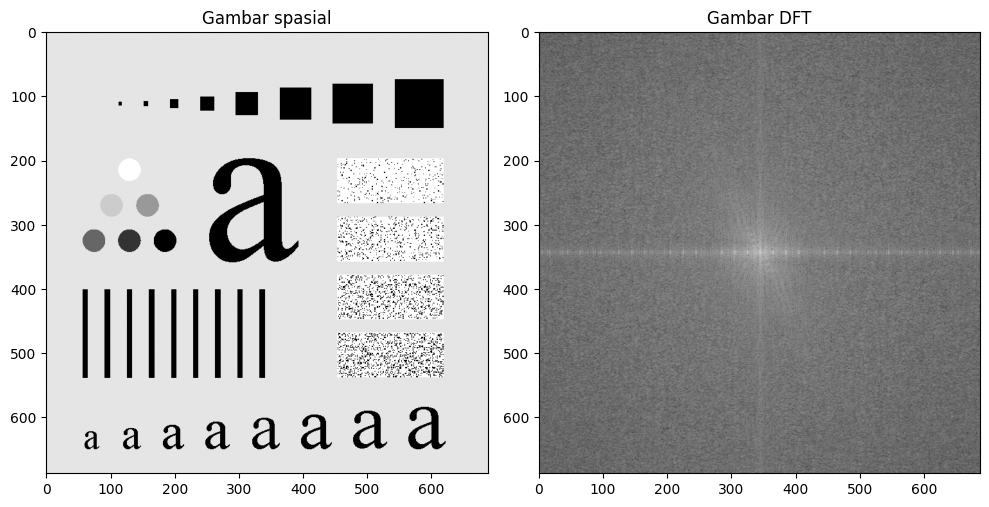

In [5]:
# from re import sub
import cv2
import matplotlib.pyplot as plt
import numpy as np
img = cv2.imread('character.tif', 0)

img_dft = np.fft.fft2(img)
img_dft = np.fft.fftshift(img_dft)
fake_dft = np.log(np.abs(img_dft)) #hasil dft agar visible by eyes.

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Gambar spasial")
plt.subplot(1,2,2)
plt.imshow(fake_dft, cmap='gray')
plt.title("Gambar DFT")
plt.tight_layout()
plt.show()

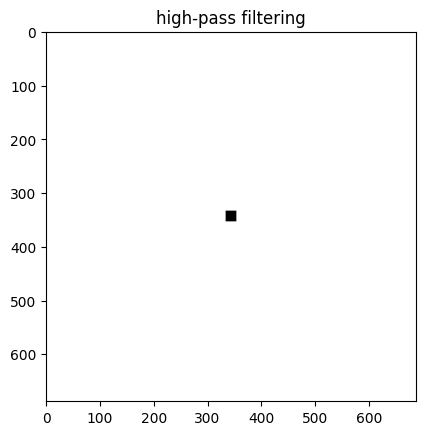

In [6]:
rows, columns = img.shape
center_row = int(rows/2)
center_col = int(columns/2)
filter = np.ones((rows, columns),np.uint8)
filter[center_row-10:center_row+10, center_col-10:center_col+10]=0
enhanced_img_high_pass = img_dft * filter
plt.title("high-pass filtering")
plt.imshow(filter, cmap='gray')
plt.show()      

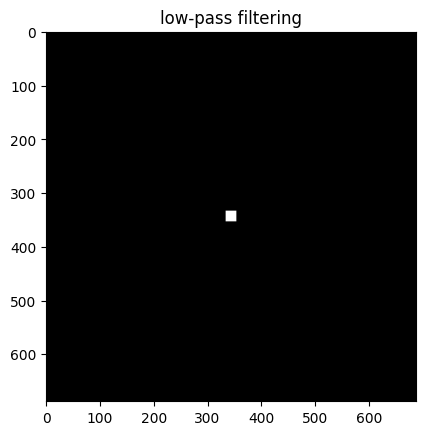

In [7]:
filter = np.zeros((rows, columns),np.uint8)
filter[center_row-10:center_row+10, center_col-10:center_col+10]=1
enhanced_img_low_pass = img_dft * filter
plt.title("low-pass filtering")
plt.imshow(filter, cmap='gray')
plt.show()      

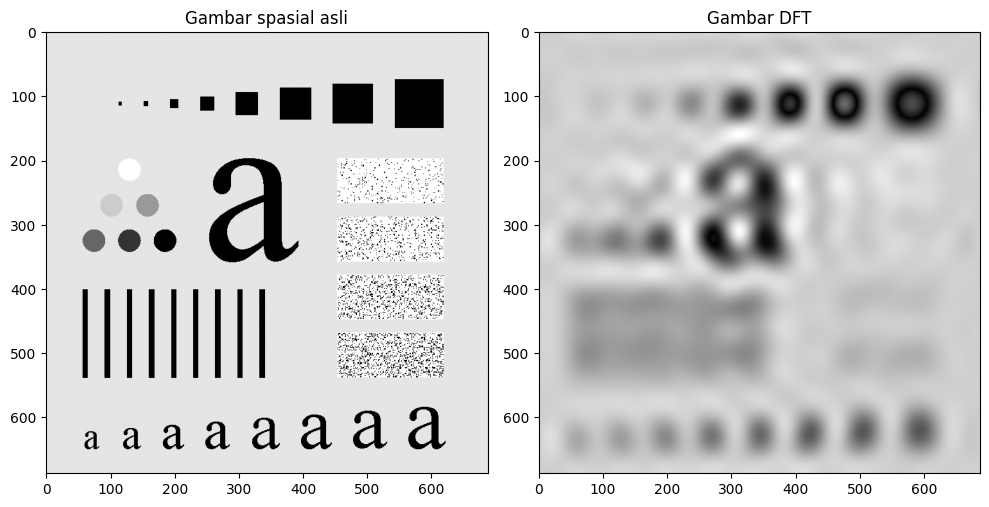

In [9]:
final_img = np.fft.ifftshift(enhanced_img_low_pass)
final_img = np.fft.ifft2(final_img)
final_img = np.abs(final_img)

plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Gambar spasial asli")
plt.subplot(1,2,2)
plt.imshow(final_img, cmap='gray')
plt.title("Gambar DFT")
plt.tight_layout()
plt.show()